In [1]:
# build large-scale data in scBank format from a group of AnnData objects
# %%
import gc
import json
from pathlib import Path
import argparse
import shutil
import traceback
from typing import Dict, List, Optional
import warnings
import numpy as np
import os
import anndata

import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from typing import Any, Dict, List, Mapping, Optional, Tuple, Union
from typing_extensions import Self, Literal
from scipy.sparse import issparse

import matplotlib as mpl
def set_vis_default(font = 1.6, circle_marker = 1.):
    mpl.rcParams['font.family'] = 'Arial'
    plt.rcParams.update(plt.rcParamsDefault)
#     %matplotlib inline
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('seaborn-v0_8-whitegrid')

    sns.set_context('paper',font_scale=font)
    plt.rcParams["legend.markerscale"] = circle_marker
    mpl.rcParams['font.family'] = 'Arial'



In [2]:
base_path = '/import/home2/xwanaf/Img2Expr/data/Reproducibility_data/PF'
file_path = Path(base_path)

file_name = 'UGE_atlas.h5ad'
atlas_adata = sc.read(file_path / file_name)
atlas_adata

AnnData object with n_obs × n_vars = 946364 × 1741
    obs: 'cell_type', 'cell_id', 'dataset_idx', 'dataset_cell_id', 'ann_finest_level', 'dataset', 'ann_level_1', 'disease', 'original_ann_nonharmonized', 'leiden_2p0', 'leiden_2p5', 'leiden_1p5', 'leiden_0p5', 'leiden_1p0', 'leiden_0p5_ct_v0', 'leiden_1p0_ct_v0', 'leiden_2p5_ct_v0', 'tmp', 'leiden_2p5_epi_v1', 'leiden_2p5_epi', 'leiden_2p5_epi_v2', 'leiden_2p5_epi_v3', 'leiden_2p5_epi_v7', 'leiden_2p5_epi_v4', 'leiden_1p_fibro_v1', 'ct_anno'
    uns: 'ann_finest_level_colors', 'dataset_colors', 'disease_colors', 'leiden_2p0_colors', 'leiden_2p5_colors', 'leiden_2p5_ct_v0_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
base_path = '/import/home2/xwanaf/Img2Expr/data/Reproducibility_data/PF'
file_path = Path(base_path)

obs_concat = pd.read_csv(file_path / 'obs_concat_atlas.csv', index_col = 0)

In [4]:
immune_cts = [
    'NK cells',
 'CD4 T cells',
 'CD8 T cells',
 'Mast cells',
 'B cells',
 'Plasma cells',
 'Interstitial Mph perivascular',
 'DC2',
 'Plasmacytoid DCs',
 'DC1',
 'Migratory DCs',
 'Classical monocytes',
 'Non-classical monocytes',
 'Monocyte-derived Mph',
 'Alveolar Mph CCL3+',
 'Alveolar Mph proliferating',
 'Alveolar macrophages',
]
endo_cts = [
    'Lymphatic EC mature',
 'EC arterial',
 'EC venous systemic',
 'EC aerocyte capillary',
 'EC general capillary',
]
stroma_cts = [
    'Pericytes',
 'SMCs',
    'myo-FB',
 'FB COL1A1+',
 'FB ECM',
 'FB ECM CHI3L2+',
 'FB ECM COL1A1+',
 'FB ECM SOX4+',
 'FB',
 'FB HAS1+',
]
epi_cts = [
    'AT2',
 'SCGB3A1+/SCGB3A2+',
 'AT1',
 'Aberrant Basaloid',
 'Ciliated',
 'Squamous',
 'Basal',
 'Basal-Prolif',
 'SCGB1A1+/SCGB3A1+/SCGB3A2+',
 'Secretory MUC5B+',
 'SMG duct',
 'SMG-Serous',
 'Ionocyte',
 'Neuroendocrine',
 'Suprabasal SCGB1A1+',
 'Secretory MUC5AC+',
 'Suprabasal',
    'Mesothelial'
]
ct_all = [immune_cts, endo_cts, stroma_cts, epi_cts]
group_titles = ['Immune', 'Endothelial', 'Stramal', 'Epithelial']

ct_lineage_map = {}
for cts, lineage in zip(ct_all, group_titles):
    for ct in cts:
        ct_lineage_map[ct] = lineage

In [5]:
df_ = atlas_adata.obs.copy()
df_ = df_.merge(obs_concat[['sample']], how = 'left', left_index = True, right_index = True)

df_['lineage'] = df_['ct_anno'].map(ct_lineage_map)
df_ct = df_.groupby('sample')['lineage'].value_counts(normalize = True).unstack(fill_value=0)
index = df_ct.max(axis = 1) > .98
df_ct[index].index

Index(['092C', '484C', '5841STDY7991477', '5841STDY7991479', 'AN12-NB',
       'AN13-NB', 'AN14-NB', 'AN5-NB', 'AN6-NB', 'D339_Biop_Nas1',
       'D363_Brus_Nas1', 'F01869', 'GRO-01_biopsy', 'GRO-09_nasal_brush',
       'GRO-10_nasal_brush', 'IPF1_Lin', 'IPF3_Lin', 'NML1_Lin', 'NP20-TB',
       'NP21-NB', 'NP21-TB', 'NP22-TB', 'NP23-NB', 'NP26-NB', 'NP26-TB',
       'NP27-NB', 'NP32-NB', 'NP38-TB', 'Polyp18CEPI', 'SC141', 'SC142',
       'SC184', 'SC84', 'SC85', 'SC87', 'SC88', 'T101', 'T120', 'T121', 'T126',
       'T137', 'T153', 'T154', 'T164', 'T165', 'T166', 'T167', 'T85', 'T89',
       'T90', 'WSSS8015042', 'WSSS8015044', 'WSSS8015045', 'WSSS8015046',
       'cc01p', 'cc02p', 'cc04p', 'cc05p', 'dd09p', 'dd10p', 'dd39p', 'dd49p',
       'h18', 'muc4659', 'muc5288'],
      dtype='object', name='sample')

/tmp/ipykernel_3447137/3958212744.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ct = df_.groupby('dataset')['lineage'].value_counts(normalize = True).unstack(fill_value=0)


<Figure size 400x3900 with 0 Axes>

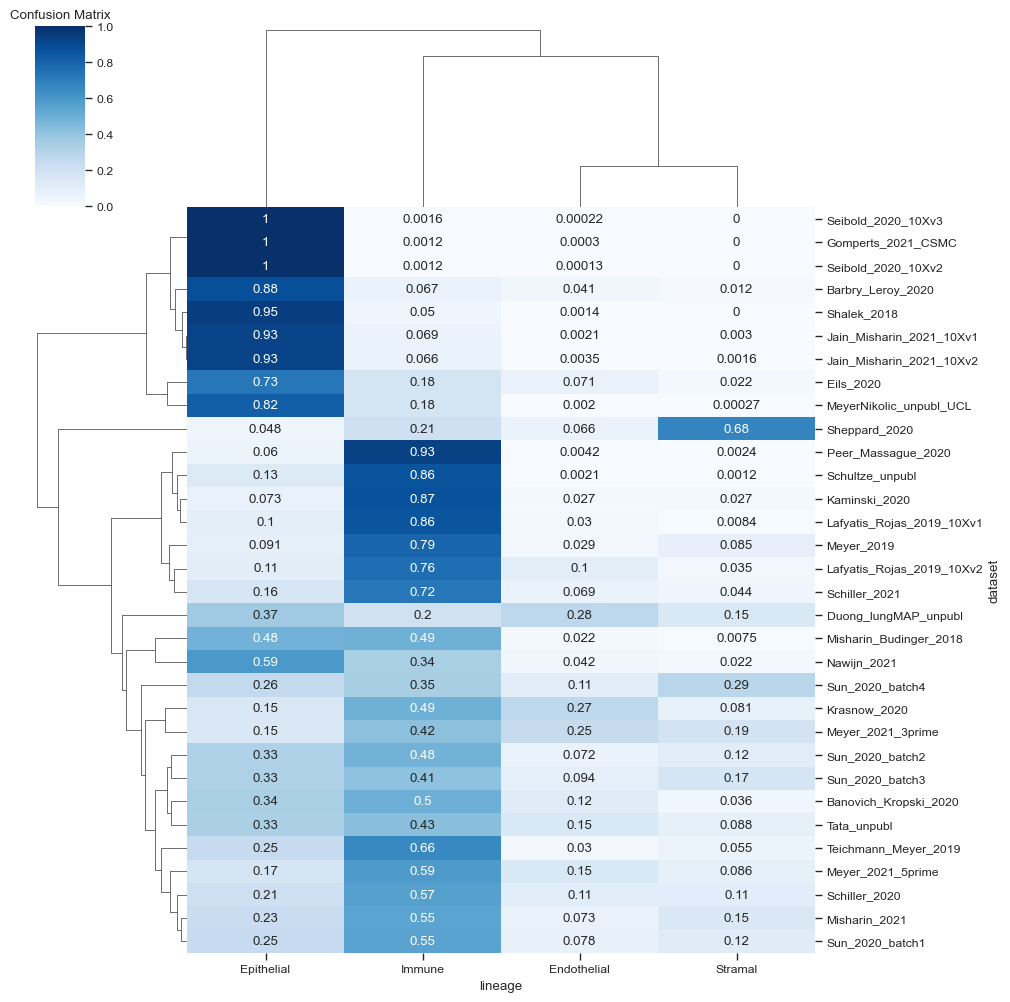

In [6]:
df_ct = df_.groupby('dataset')['lineage'].value_counts(normalize = True).unstack(fill_value=0)

set_vis_default(font = 1.)
plt.figure(figsize=(4, 39))
sns.clustermap(
    df_ct, 
    annot=True, 
#     fmt='d', 
    cmap='Blues', 
    vmax = 1
)
plt.title('Confusion Matrix')
# plt.ylabel('Actual')
# plt.xlabel('Predicted')
plt.show()
plt.close()



In [7]:
def get_mapdict_from2col(df, col1, col2):
    mapdict = dict(df.groupby(col1)[col2].value_counts().groupby(col1).idxmax().values)
    return mapdict

In [10]:
df_vis

,disease,ct_anno,prop
0,pulmonary fibrosis,AT1,0.017467
1,pulmonary fibrosis,AT1,0.112245
2,pulmonary fibrosis,AT1,0.078534
3,pulmonary fibrosis,AT1,0.024390
4,pulmonary fibrosis,AT1,0.019523
...,...,...,...
16695,pulmonary fibrosis,myo-FB,0.000000
16696,pulmonary fibrosis,myo-FB,0.000000
16697,normal,myo-FB,0.000000
16698,normal,myo-FB,0.000000


In [12]:
df_vis['ct_anno'].value_counts()

ct_anno
AT1                              334
AT2                              334
Aberrant Basaloid                334
Alveolar Mph CCL3+               334
Alveolar Mph proliferating       334
Alveolar macrophages             334
B cells                          334
Basal                            334
Basal-Prolif                     334
CD4 T cells                      334
CD8 T cells                      334
Ciliated                         334
Classical monocytes              334
DC1                              334
DC2                              334
EC aerocyte capillary            334
EC arterial                      334
EC general capillary             334
EC venous systemic               334
FB                               334
FB COL1A1+                       334
FB ECM                           334
FB ECM CHI3L2+                   334
FB ECM COL1A1+                   334
FB ECM SOX4+                     334
FB HAS1+                         334
Interstitial Mph perivascular 

Using 335 samples.


/tmp/ipykernel_3447137/510777312.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels([_.get_text() for _ in axs.get_xticklabels()], rotation=90)


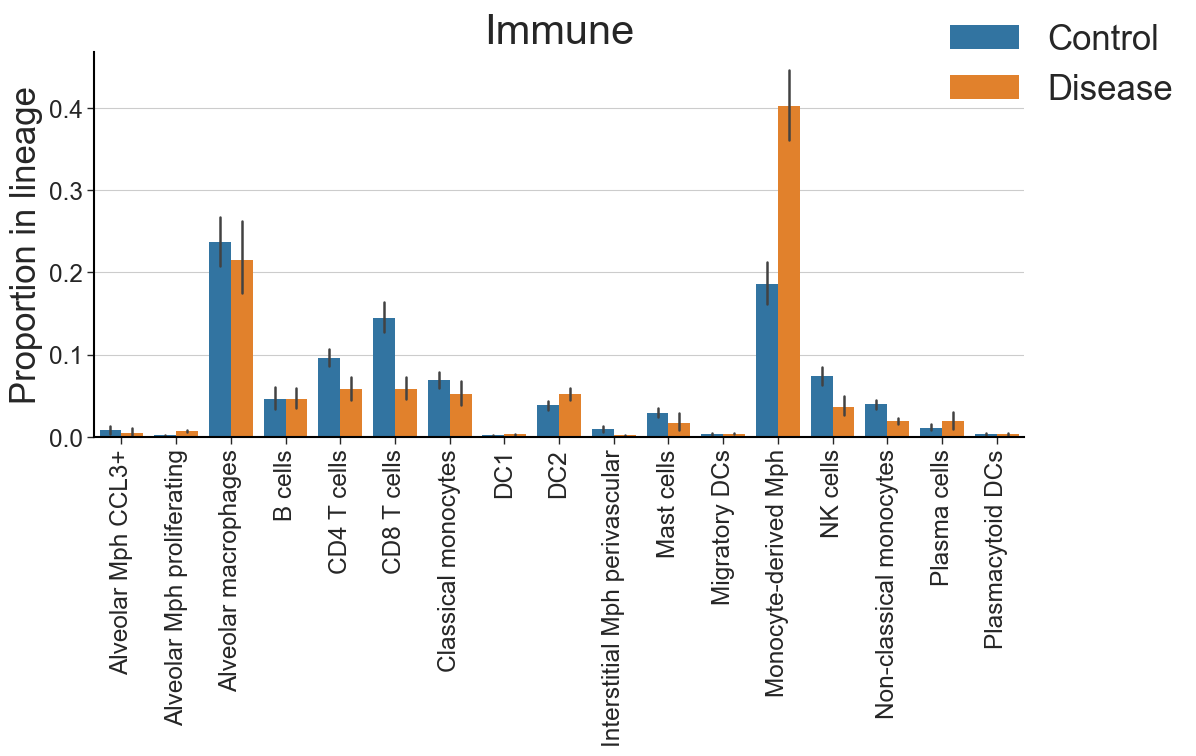

Using 128 samples.


/tmp/ipykernel_3447137/510777312.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels([_.get_text() for _ in axs.get_xticklabels()], rotation=90)


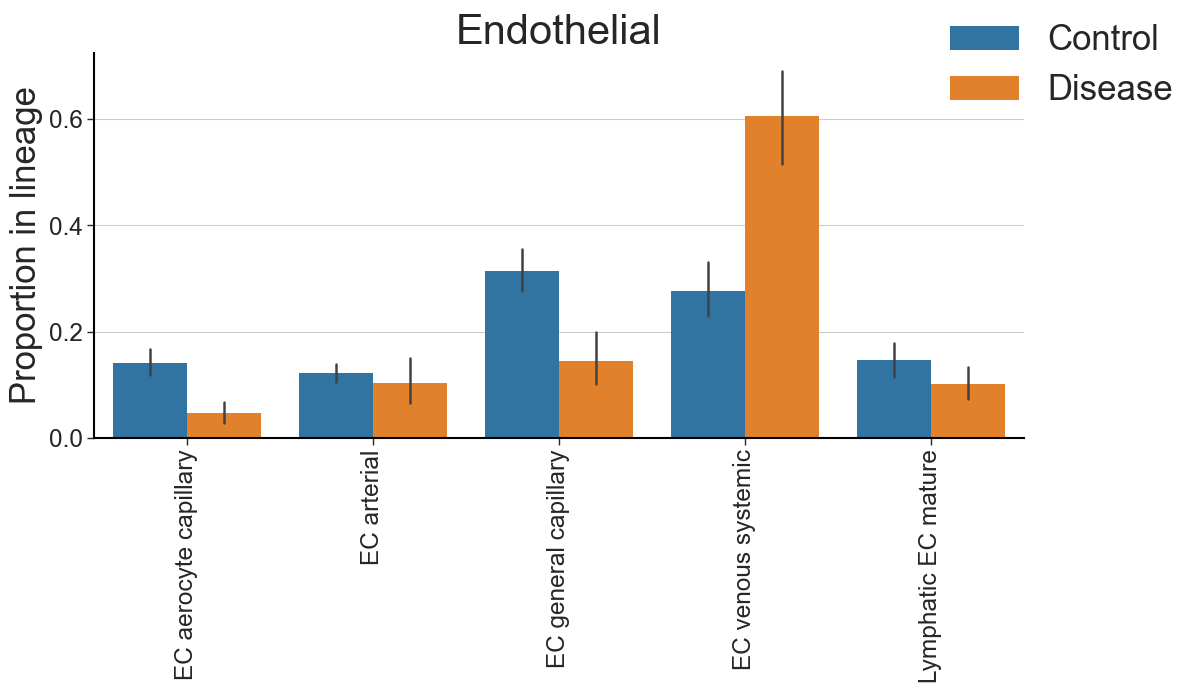

Using 103 samples.


/tmp/ipykernel_3447137/510777312.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels([_.get_text() for _ in axs.get_xticklabels()], rotation=90)


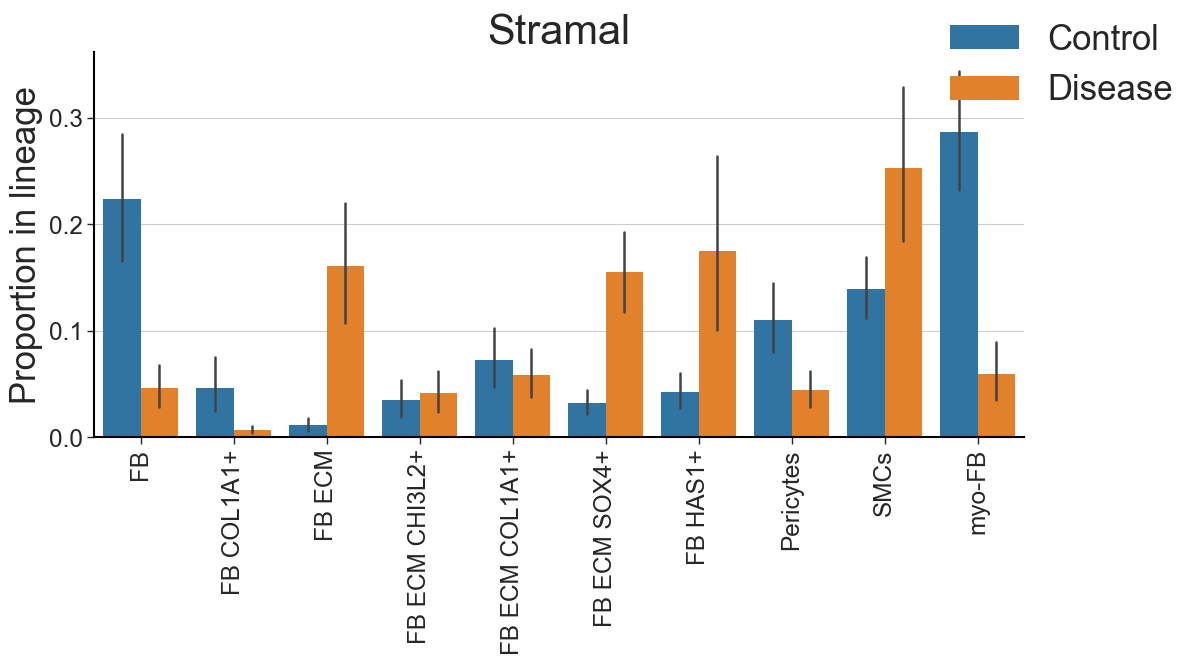

Using 334 samples.


/tmp/ipykernel_3447137/510777312.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels([_.get_text() for _ in axs.get_xticklabels()], rotation=90)


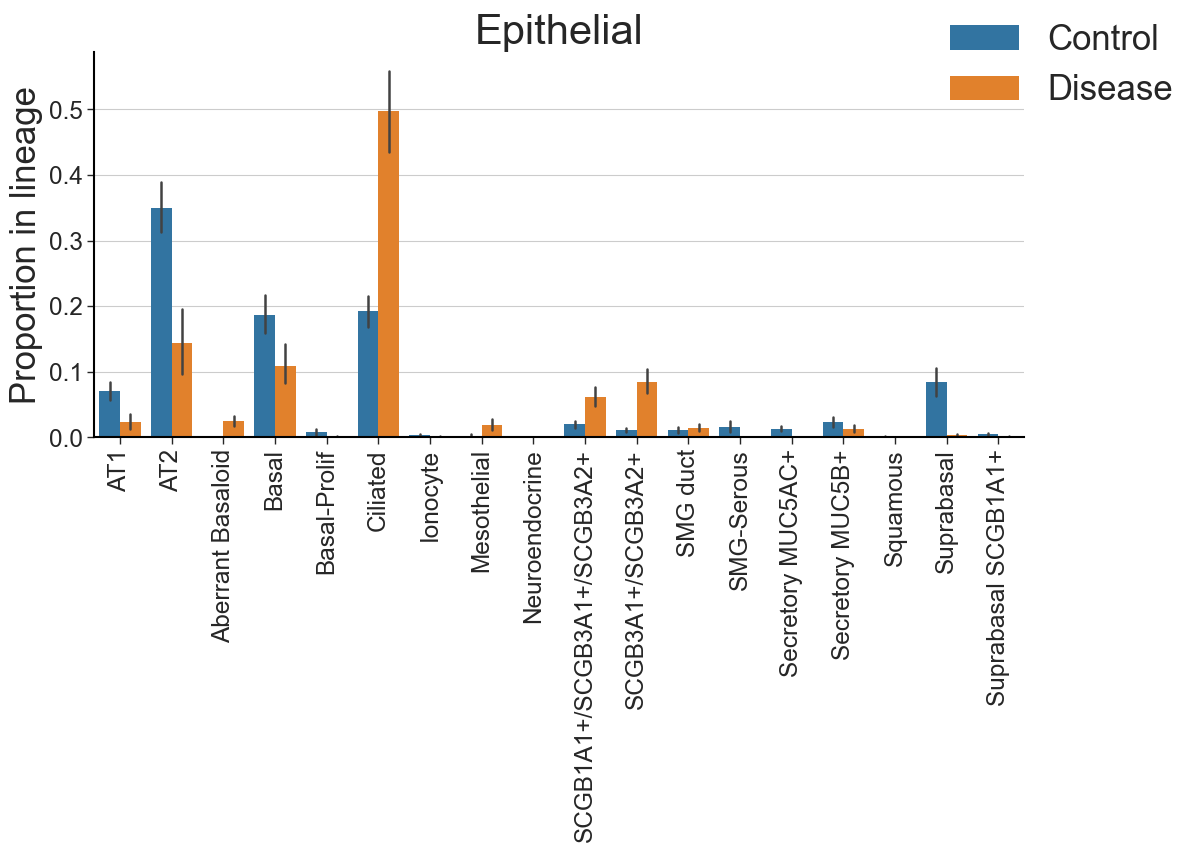

In [13]:
sample2disease = get_mapdict_from2col(df_, col1 = 'sample', col2 = 'disease')
# cts = ct_all[0]
for cts, lineage in zip(ct_all, group_titles):
    df_sub = df_.loc[df_['ct_anno'].isin(cts)]
    value_counts = df_sub['sample'].value_counts()
    sl_samples = value_counts[value_counts > 100].index.tolist()
    print(f'Using {len(sl_samples)} samples.')
    df_sub = df_sub[df_sub['sample'].isin(sl_samples)]

    df_ct = df_sub.groupby('sample')['ct_anno'].value_counts(normalize = True).unstack(fill_value=0)
    df_ct['disease'] = df_ct.index.map(sample2disease)

    df_vis = df_ct.melt(
        id_vars=['disease'], 
        value_vars=None, 
        var_name=None, 
        value_name='prop'
    )

    df_vis = df_vis.loc[df_vis['ct_anno'].isin(cts)]
    set_vis_default(font = 2)
    fig, axs = plt.subplots(1,1,figsize = (12, 5))
    sns.barplot(
        df_vis, 
        x = 'ct_anno', y = 'prop', 
        hue = 'disease', hue_order = ['normal', 'pulmonary fibrosis'], 
        ax = axs
    )
    # ax.set_ylim([0,1])
    axs.legend(bbox_to_anchor=(1., 1))
    axs.set_xlabel('', fontsize = 25)
    axs.set_ylabel('Proportion in lineage', fontsize = 25)
    axs.set_title(lineage, fontsize = 30)

    # new_labels = ['shuffle all', 'shuffle within cell type', 'diffusion', 'istar']
    # for t, l in zip(ax.get_legend().texts, new_labels):
    #     t.set_text(l)
    axs.set_xticklabels([_.get_text() for _ in axs.get_xticklabels()], rotation=90) 

    axs.spines['right'].set_visible(False)
    axs.spines['top'].set_visible(False)
    for spine in ['left', 'bottom']:
        axs.spines[spine].set_color('black')        
        axs.spines[spine].set_linewidth(1.5)


    from matplotlib.patches import Patch
    legend_handles, labels = axs.get_legend_handles_labels()  
    legend_labels = ['Control', 'Disease']  
    # axs.legend(handles, new_labels, title='Disease Type')  

    plt.legend(
        legend_handles, legend_labels, 
        title='', bbox_to_anchor=(1.05, 1), 
        fontsize = 25,
        bbox_transform=plt.gcf().transFigure, loc='upper right'
    )
    # plt.legend(handles, lut, title='Species',
    #            bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper right')


#     plt.savefig(f'./save_figs_si/Cell_type_prop_{lineage}.png', format='png', dpi = 200, bbox_inches='tight',pad_inches=.2)
    plt.show()
    plt.close()

